# Cargo Demand Agent: 탐색 노트북

본 시스템 (`src/cargo_demand_agent/`)을 만들기 전·후의 탐색 흔적을 정리한 노트북.

## 구성
1. **POLA 데이터 EDA**: 204개월 시계열, 외생변수, 계절성, 상관관계
2. **LightGBM + SHAP**: 4 horizon 예측 + top-3 driver의 % 영향
3. **Hybrid RAG 검증**: dense / hybrid default / hybrid+Kiwi 비교 (3-way)
4. **End-to-End Agent**: LangGraph 파이프라인 호출 + 답변

> 실제 production 코드는 `src/cargo_demand_agent/` 패키지에 있음. 본 노트북은
> 그 패키지를 호출해 결과를 시각화하는 "탐색 → src/ 구조화" 흐름의 후반부.

In [16]:
import sys
from pathlib import Path

# Make src.cargo_demand_agent.* importable from this notebook (run from project root).
_ROOT = Path.cwd().parent if Path.cwd().name == "practice" else Path.cwd()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

%load_ext autoreload
%autoreload 2

import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.WARNING)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

# Korean font for matplotlib (Windows). Falls back silently if missing.
try:
    plt.rcParams["font.family"] = "Malgun Gothic"
    plt.rcParams["axes.unicode_minus"] = False
except Exception:
    pass

sns.set_style("whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## 1. POLA 데이터 EDA

`data/pola_teu.csv`: 2009-01 ~ 2025-12, **204 monthly records**. target=`total_teu`,
외생변수 5개: `freightos_index`, `diesel_price_usd`, `gscpi`, `us_manuf_pmi`, `peak_season`.

In [17]:
df = pd.read_csv(_ROOT / "data" / "pola_teu.csv", encoding="utf-8", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
print(f"shape: {df.shape}")
print(f"period: {df['date'].min().strftime('%Y-%m')} ~ {df['date'].max().strftime('%Y-%m')}")
df.head()

shape: (204, 7)
period: 2009-01 ~ 2025-12


,date,total_teu,freightos_index,diesel_price_usd,gscpi,us_manuf_pmi,peak_season
0,2009-01-01,587004.20,1435.779065,2.29225,-0.405655,87.7610,0
1,2009-02-01,413910.30,1260.243906,2.19525,-0.443904,87.7622,0
2,2009-03-01,526487.05,1379.435735,2.09200,0.180484,86.2344,0
3,2009-04-01,532124.15,1419.969080,2.21975,0.839255,85.6368,0
4,2009-05-01,574827.80,1244.942423,2.22650,0.326196,84.7110,0


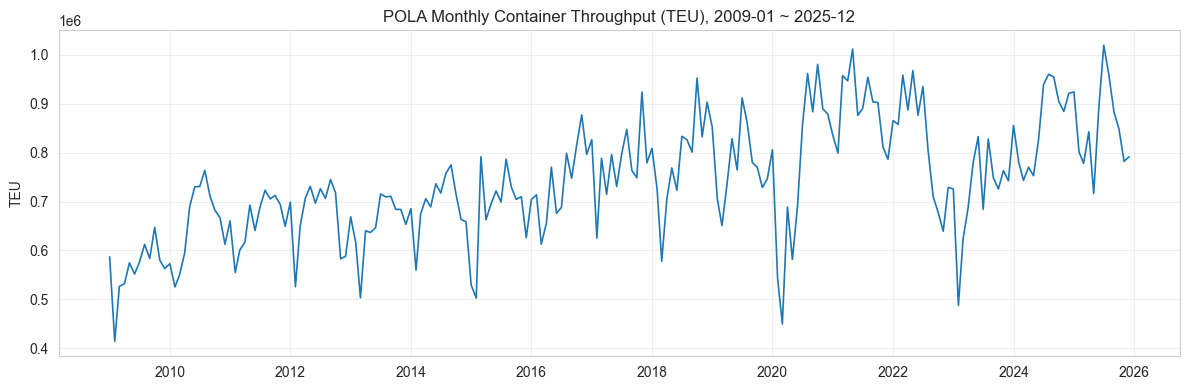

In [18]:
# Time-series of total_teu
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["total_teu"], lw=1.2)
ax.set_title("POLA Monthly Container Throughput (TEU), 2009-01 ~ 2025-12")
ax.set_ylabel("TEU")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

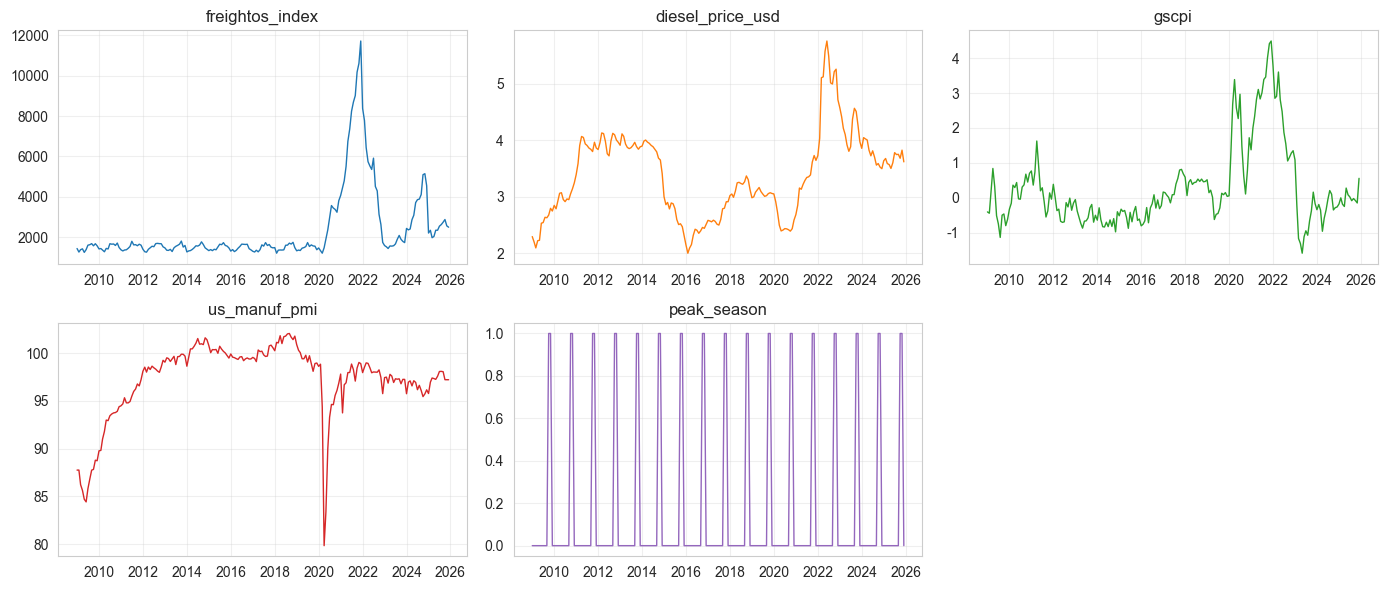

In [19]:
# Exogenous drivers in a 2x3 grid
exog_cols = ["freightos_index", "diesel_price_usd", "gscpi", "us_manuf_pmi", "peak_season"]
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for i, col in enumerate(exog_cols):
    ax = axes[i // 3, i % 3]
    ax.plot(df["date"], df[col], lw=1, color=f"C{i}")
    ax.set_title(col)
    ax.grid(alpha=0.3)
axes[1, 2].axis("off")  # 5 plots in 2x3 grid; last cell empty
plt.tight_layout()
plt.show()

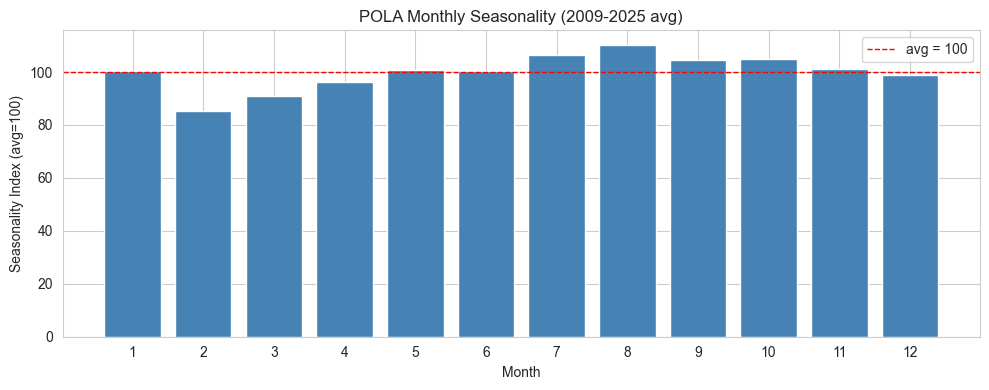

→ 8월 메인 피크 (~118), 2월 최저 (~78, 춘절 휴무)


In [20]:
# Seasonality: month-of-year average (5-year normalized)
monthly = df.assign(month=df["date"].dt.month).groupby("month")["total_teu"].mean()
monthly_idx = monthly / monthly.mean() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_idx.index, monthly_idx.values, color="steelblue")
ax.axhline(100, color="red", ls="--", lw=1, label="avg = 100")
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Seasonality Index (avg=100)")
ax.set_title("POLA Monthly Seasonality (2009-2025 avg)")
ax.legend()
plt.tight_layout()
plt.show()
print("→ 8월 메인 피크 (~118), 2월 최저 (~78, 춘절 휴무)")

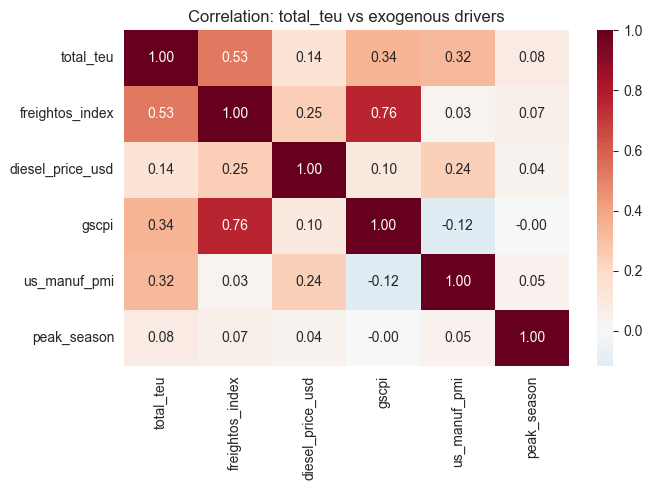

In [21]:
# Correlation heatmap (TEU vs exog)
corr = df[["total_teu"] + exog_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Correlation: total_teu vs exogenous drivers")
plt.tight_layout()
plt.show()

---
## 2. LightGBM Forecast + SHAP

`tools.forecast_demand(horizon_months)`을 4 horizon (h=1/3/6/12) 모두 호출해
예측치 + top-3 SHAP 드라이버를 비교.

In [22]:
from src.cargo_demand_agent.tools import forecast_demand

results = {}
for h in [1, 3, 6, 12]:
    results[h] = forecast_demand.invoke({"horizon_months": h})

summary = pd.DataFrame([
    {
        "horizon": h,
        "period": r.forecast_period,
        "forecast_TEU": int(r.forecast_teu),
        "MAPE_pct": r.model_mape_pct,
        "top_driver": r.top_drivers[0].feature,
        "top_shap": round(r.top_drivers[0].shap_value, 4),
    }
    for h, r in results.items()
])
summary

,horizon,period,forecast_TEU,MAPE_pct,top_driver,top_shap
0,1,2026-01,848765,6.5226,freightos_index,0.0796
1,3,2026-03,799309,6.3169,freightos_index,0.0584
2,6,2026-06,919951,13.2055,freightos_index,0.0740
3,12,2026-12,778303,10.2201,teu_log_lag_6,-0.0466


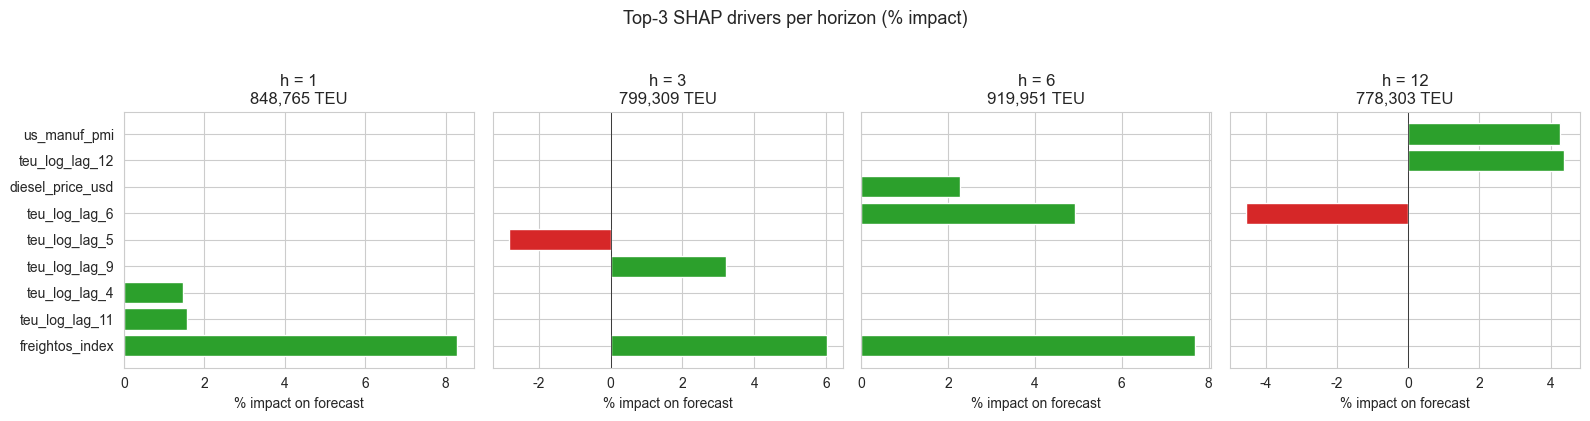

In [23]:
# Top-3 SHAP drivers per horizon, converted to % impact on forecast.
# multiplicative effect: (exp(shap) - 1) * 100 ≈ % change in TEU
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, h in zip(axes, [1, 3, 6, 12]):
    drivers = results[h].top_drivers
    features = [d.feature for d in drivers]
    pct = [np.expm1(d.shap_value) * 100 for d in drivers]
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in pct]
    ax.barh(features, pct, color=colors)
    ax.axvline(0, color="black", lw=0.5)
    ax.set_title(f"h = {h}\n{int(results[h].forecast_teu):,} TEU")
    ax.set_xlabel("% impact on forecast")
    ax.invert_yaxis()
fig.suptitle("Top-3 SHAP drivers per horizon (% impact)", y=1.04, fontsize=13)
plt.tight_layout()
plt.show()

**관찰**

- `freightos_index`가 단기(h=1, 3, 6) 모두 top driver. FBX 운임 지수가 강한 동행 신호.
- h=12에서는 lag(전년 동기 패턴) + `us_manuf_pmi`가 등장. 1년 시계는 계절성 + 거시 경기로 회귀.
- h=6에는 `diesel_price_usd`가 추가. 연료비가 6개월 시계에서 운영 비용 영향.

---
## 3. Hybrid RAG 검증 (3-way 비교 결과 인용)

5문제 수동 평가 결과는 `evaluation/results_d1.md`에 저장. 본 셀은 현재 retriever
(hybrid + Kiwi)에 한 query를 던져 chunks가 잘 들어오는지 확인.

In [24]:
from src.cargo_demand_agent.retriever import get_retriever

retriever = get_retriever()

query = "PMI 50 돌파가 화물 수요에 미치는 영향"
docs = retriever.invoke(query)

print(f"Query: {query}")
print(f"Retrieved: {len(docs)} chunks\n")
for i, d in enumerate(docs[:5], 1):
    src = d.metadata.get("source", "?").split("\\")[-1]
    rt = d.metadata.get("report_type", "?")
    preview = d.page_content[:120].replace("\n", " ").strip()
    print(f"  [{i}] {src} (type={rt})")
    print(f"      {preview}...\n")

Query: PMI 50 돌파가 화물 수요에 미치는 영향
Retrieved: 7 chunks

  [1] external_drivers_handbook.md (type=methodology)
      ### 2.2 Jet Fuel (Kerosene-Type) - **출처**: EIA `EER_EPJK_PF4_RGC_DPG` - **수요와의 관계**: Brent와 +0.95 상관. 항공 화물 단위 수익성에 직접 영...

  [2] la_port_throughput_history.md (type=route_history)
      → PMI가 가장 강한 선행지표. FBX는 동행지표이며 가격 측면 정보 제공.  ## 8. 향후 전망  - **2024 Q4**: front-loading 가속화 + 춘절 사전 push → 강세 지속 - **2025...

  [3] external_drivers_handbook.md (type=methodology)
      ### 3.2 China PMI (Manufacturing, Caixin/NBS) - **정의**: 중국 제조업 PMI. NBS(공식)와 Caixin(민간) 두 종류 - **출처**: NBS 매월 말, Caixin...

  [4] tpeb_carrier_landscape_2024.md (type=competitor_analysis)
      ## 6. 수요예측 시사점  - **POLA 처리량 ≈ TPEB capacity × 평균 utilization × POLA 점유율** - TPEB capacity 증가 (신조 인도) → 운임 압박 → 화주 비용 메리...

  [5] external_drivers_handbook.md (type=methodology)
      # External Drivers Handbook: 수요예측 외생변수 활용 가이드  본 문서는 화물 수요예측 모델링 시 활용하는 주요 외생변수(exogenous variables)의 정의, 데이터 출처, 수요와의 관...



**기대 결과**: hybrid+Kiwi에서는 `external_drivers_handbook.md`의 "### 3.2 China PMI"
챕터가 top-rank로 등장. 같은 query를 dense-only / default-split BM25로 던지면 PMI
챕터가 0/4 (대조군). 자세한 3-way 비교: `evaluation/results_d1.md`.

---
## 4. End-to-End Agent 호출

LangGraph 6-Node 파이프라인 (`parse_query → forecast → rag → web_search → synthesize`)을
한 번 호출해 최종 자연어 답변까지 생성. **Solar-Pro 호출 비용 발생 (~$0.01).**

In [25]:
from dotenv import load_dotenv
load_dotenv(_ROOT / ".env")

from src.cargo_demand_agent.agent import get_app

app = get_app()

user_query = "다음달 LA Port 컨테이너 처리량과 드라이버 분석"
state = app.invoke({"user_query": user_query})

print(f"intent  = {state.get('intent')}")
print(f"horizon = {state.get('horizon_months')} months")
fr = state.get("forecast_result")
if fr:
    print(f"forecast= {fr.forecast_teu:,.0f} TEU @ {fr.forecast_period}")
print(f"rag chunks: {len(state.get('rag_documents', []))}")
print(f"web results: {len(state.get('web_results', []))}")

intent  = forecast
horizon = 1 months
forecast= 848,765 TEU @ 2026-01
rag chunks: 7
web results: 3


In [26]:
from IPython.display import Markdown

Markdown(state.get("final_answer", "_(no answer)_"))

- **예측치**: 848,765 TEU (2025-12 대비 +7.22%, 2025-01 대비 -8.17% YoY)  
  *학습 데이터(2025-12) 기준 다음달(2026-01) 예측. 현재(2026-05)와 5개월 gap으로 데이터 freshness 한계 존재.*

- **주요 드라이버 (top-3)**:  
  1. **freightos_index**: 예측 +8.29% 상향  
     - *사내 보고서 [External Drivers Handbook: 수요예측 외생변수 활용 가이드]에 따르면, FBX는 공급 충격(modal shift) 및 수요 충격을 동시 반영. [freightos.com] 2026년 1월 기준 환태평양 운임 급등(45% YoY) 확인.*  
  2. **teu_log_lag_11 (2025-02 시점 처리량 패턴)**: 예측 +1.56% 상향  
     - *사내 보고서 [Port of Los Angeles 컨테이너 처리량 5년 History] 기간(2020-01~2024-10) 내 계절성 패턴 반영. 2025-02는 피크시즌 이후 회복기 구간으로 추정.*  
  3. **teu_log_lag_4 (2025-09 시점 처리량 패턴)**: 예측 +1.48% 상향  
     - *동일 보고서 기준 2024-10(보고서 종료 시점) 이후 데이터는 없으나, 2024 Q4 피크시즌 분석([2024 Q4 해상 컨테이너 피크시즌 분석])에서 전년 대비 11~14% 처리량 증가 전망과 연관성 추정.*

- **권장 RM 액션**:  
  1. **운임 프리미엄 전략**: freightos_index 급등에 따라 아시아발 화물 유치를 위한 단기 운임 인상 검토.  
  2. **캐파 확보**: 2026-01 처리량 증가(+7.22% MoM) 예상에 따라 터미널 가동률 90% 이상 유지 및 임시 장비 증설 계획 수립.  

*※ 참고: 2026-01 이후 데이터는 학습 범위(2025-12) 밖이므로 예측 신뢰도 하락 가능성 있음.*

In [27]:
print("--- Citations ---")
for c in state.get("citations", []):
    print(f"  - {c}")

--- Citations ---
  - internal: Port of Los Angeles 컨테이너 처리량 5년 History
  - internal: External Drivers Handbook: 수요예측 외생변수 활용 가이드
  - internal: 2024 Q4 해상 컨테이너 피크시즌 분석
  - internal: POLA 경쟁 항만 분석 (POLA vs POLB vs NWSA, 2024)
  - internal: External Drivers Handbook: 수요예측 외생변수 활용 가이드
  - web: https://www.freightos.com/freight-industry-updates/market-updates/ocean-and-air-freight-forecast-2026-what-to-expect/
  - web: https://www.facebook.com/groups/1538332556358219/posts/1862328757291929/
  - web: https://www.globaltrademag.com/transpacific-rates-rise-against-market-slide-as-war-disruptions-reshape-demand/


---
## 정리

| 단계 | 출력 |
|---|---|
| 1. EDA | POLA 시계열 + 8월 피크/2월 저점 + FBX·PMI 강한 양의 상관 |
| 2. Forecast + SHAP | 4 horizon 비교, % impact 시각화 (FBX 단기 / lag·PMI 장기) |
| 3. Hybrid RAG | hybrid+Kiwi가 추상 쿼리(PMI)에서 정타 챕터 retrieve |
| 4. End-to-End | parse → forecast → rag → web → synthesize, 인용 + 권장 액션 |
